In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Take grayscale image of size 512x512, add some Gaussian noise and perform the following
operations in frequency domain –

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

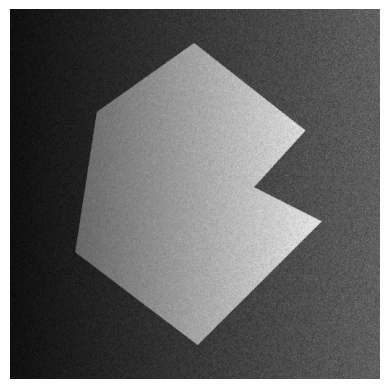

In [7]:
img = cv2.imread('septagon_noisy_shaded.tif', cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (512,512))
plt.imshow(img, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

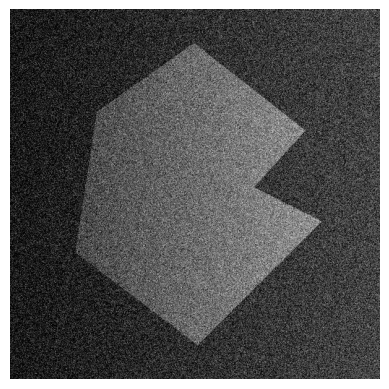

In [8]:
mean = 0
sigma = 20
gsn  = np.random.normal(mean, sigma, img.shape)
nimg = np.clip(img+gsn, 0, 255).astype(np.uint8)

plt.imshow(nimg, cmap='gray')
plt.axis('off')

In [26]:
def dft(img):
    return np.fft.fftshift(np.fft.fft2(img))
def idft(fshift):
    return np.abs(np.fft.ifft2(np.fft.ifftshift(fshift)))


(a) Apply 4th order Butterworth and Gaussian low pass filter to analyze their performance quantitatively

In [29]:
def butterworth_lowpass(img, d0, n):
    r,c = img.shape
    u,v = np.meshgrid(np.arange(c), np.arange(r))
    d = np.sqrt((u-c//2)**2 + (v-r//2)**2)
    b = 1.0/(1+(d/d0)**(2*n))

    return b

In [38]:
def gaussian_lowpass(img, d0):
    r,c = img.shape
    u,v = np.meshgrid(np.arange(c), np.arange(r))
    d = np.sqrt((u-c//2)**2 + (v-r//2)**2)
    g = np.exp((-d**2)/(2*d0**2))

    return g

In [47]:
def ideal_lowpass(img, d0):
    r,c = img.shape
    u,v = np.meshgrid(np.arange(c), np.arange(r))
    d = np.sqrt((u-c//2)**2 + (v-r//2)**2)
    return (d<d0).astype(float)

In [23]:
def apply_filter(img, filter_kernel):
    f = dft(img)
    f_filtered = f*filter_kernel
    return idft(f_filtered)

In [41]:
def psnr(nimg, img):
    mse = np.mean((nimg-img)**2)

    return 20*np.log10(255.0/np.sqrt(mse)) if mse!=0 else float('inf')

PSNR :  34.51213725640889


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

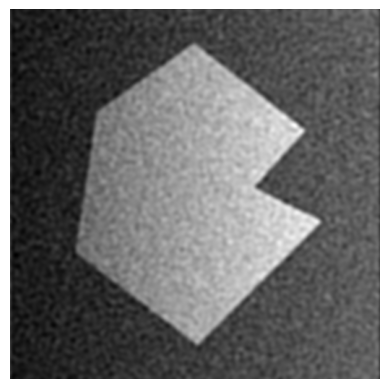

In [44]:
d0 = 50
butter_mask = butterworth_lowpass(nimg, d0, n=4)
bimg = apply_filter(nimg, butter_mask)

ps = psnr(bimg, img)
print("PSNR : ", ps)

plt.imshow(bimg, cmap='gray')
plt.axis('off')

PSNR:  33.390102079279316


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

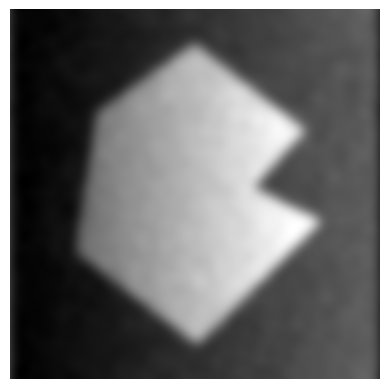

In [45]:
gaussian_mask = gaussian_lowpass(img, 10)
gaussian_img = apply_filter(nimg, gaussian_mask)

ps = psnr(gaussian_img, img)
print("PSNR: ", ps)

plt.imshow(gaussian_img, cmap='gray')
plt.axis('off')

(b) Observe the ringing effect of ideal low pass filter on the image. Use different radius (D0) of ideal low pass filter and display their results

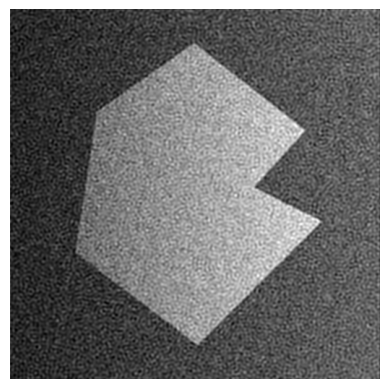

In [48]:
d0_list = [10,30,60,100]
for d0 in d0_list:
    ideal = ideal_lowpass(img, d0)
    ideal_res = apply_filter(nimg, ideal)
    plt.imshow(ideal_res, cmap='gray')
    plt.axis('off')

(c) Perform edge detection of given the noise and clean image using ideal and Gaussian high pass filters.

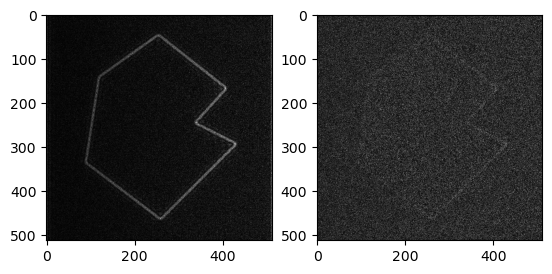

In [51]:
d0 = 30
ideal_hp = 1 - ideal_lowpass(img, d0)

ideal_hp_img = apply_filter(img, ideal_hp)
ideal_hp_nimg = apply_filter(nimg, ideal_hp)

plt.subplot(1,2,1)
plt.imshow(ideal_hp_img, cmap='gray')
plt.subplot(1,2,2)
plt.imshow(ideal_hp_nimg, cmap='gray')
plt.show()

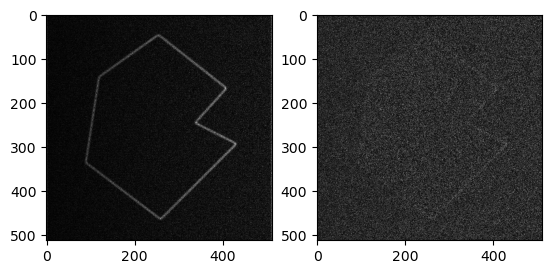

In [52]:
gaus_hp = 1 - gaussian_lowpass(img, d0)

gaus_hp_img = apply_filter(img, gaus_hp)
gaus_hp_nimg = apply_filter(nimg, gaus_hp)

plt.subplot(1,2,1)
plt.imshow(gaus_hp_img, cmap='gray')
plt.subplot(1,2,2)
plt.imshow(gaus_hp_nimg, cmap='gray')
plt.show()